# **🍔 Analisis Mitigasi Risiko Transaksi Food Delivery: Prediksi Pembatalan & Refund**
---
**Deskripsi**: Proyek data mining ini bertujuan untuk membangun model prediktif yang mampu mengidentifikasi potensi kegagalan transaksi (pembatalan atau refund) sebelum proses selesai. Analisis berfokus pada variabel operasional—seperti tingkat keluhan, jarak kirim, dan rating pelanggan—untuk meminimalkan kerugian finansial dan meningkatkan efisiensi layanan.

**Metode yang digunakan:**
1. Random Forest Classification: Algoritma ensemble yang digunakan untuk mengklasifikasikan status pesanan (Selesai, Dibatalkan, atau Refund) dengan tingkat akurasi dan stabilitas yang tinggi.
2. Feature Importance: Teknik untuk mengidentifikasi variabel kritis (seperti Tingkat_Keluhan atau Rating_Pelanggan) yang paling berpengaruh dalam memicu terjadinya pembatalan pesanan.
3. Confusion Matrix Analysis: Alat evaluasi mendalam untuk memastikan model mampu mendeteksi kasus "langka" seperti refund meskipun data bersifat tidak seimbang (imbalanced data).

**Insight Utama:** Menemukan korelasi antara rating rendah dan keluhan pelanggan sebagai sinyal dini kegagalan transaksi, memungkinkan tim operasional untuk melakukan intervensi proaktif guna menjaga kepuasan pelanggan.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Tentukan lokasi file
file_path = '/content/drive/MyDrive/Colab Notebooks/synthetic_fooddelivery_dataset.csv'

# Baca file CSV
df = pd.read_csv(file_path)

# Tampilkan 5 data teratas untuk memastikan data masuk
df.head()

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,9000,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,21000,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,33500,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai


In [4]:
df['Jarak_Kirim_KM'] = df['Jarak_Kirim_KM'].fillna(df['Jarak_Kirim_KM'].median())
df['Waktu_Tunggu_Menit'] = df['Waktu_Tunggu_Menit'].fillna(df['Waktu_Tunggu_Menit'].median())
limit = df['Harga_Pesanan'].quantile(0.95)
df['Harga_Pesanan'] = np.where(df['Harga_Pesanan'] > limit, limit, df['Harga_Pesanan'])

In [13]:
# --- UPDATE BAGIAN FITUR DAN TARGET ---

# 1. Encode Kategori_Menu
le_kat = LabelEncoder()
df['Kategori_Enc'] = le_kat.fit_transform(df['Kategori_Menu'].astype(str))

# 2. Encode Tingkat_Keluhan
le_keluhan = LabelEncoder()
df['Keluhan_Enc'] = le_keluhan.fit_transform(df['Tingkat_Keluhan'].astype(str))

# 3. Masukkan FITUR BARU: Kategori_Enc dan Rating_Pelanggan
# Rating sangat penting: Biasanya Rating rendah = Refund/Batal
X = df[['Harga_Pesanan', 'Jarak_Kirim_KM', 'Waktu_Tunggu_Menit',
        'Status_Promo', 'Keluhan_Enc', 'Kategori_Enc', 'Rating_Pelanggan']]
y = df['Status_Pesanan']

# Pastikan Status_Promo jadi angka
X['Status_Promo'] = X['Status_Promo'].astype(int)

# Encode Label Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

/tmp/ipykernel_486/2995500105.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Status_Promo'] = X['Status_Promo'].astype(int)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

/tmp/ipykernel_486/1711578599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status_Pesanan', data=df, palette='viridis')


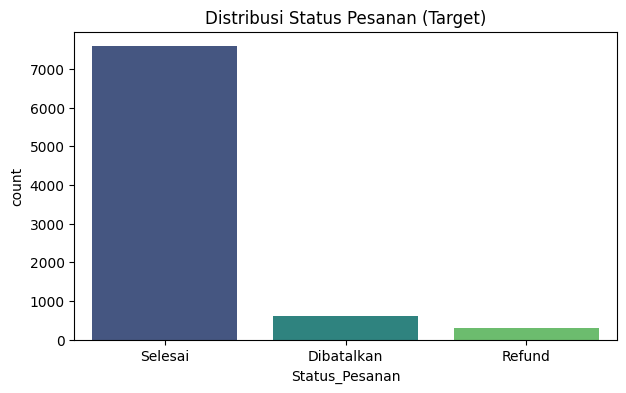

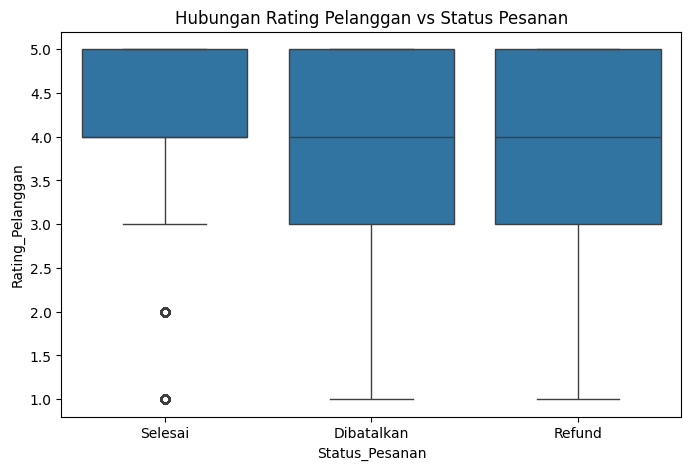

In [7]:
# Visualisasi Distribusi Target (Membuktikan Data Imbalance)
plt.figure(figsize=(7,4))
sns.countplot(x='Status_Pesanan', data=df, palette='viridis')
plt.title('Distribusi Status Pesanan (Target)')
plt.show()

# Hubungan Rating Pelanggan dengan Status Pesanan
plt.figure(figsize=(8,5))
sns.boxplot(x='Status_Pesanan', y='Rating_Pelanggan', data=df)
plt.title('Hubungan Rating Pelanggan vs Status Pesanan')
plt.show()

In [8]:
# --- UPDATE BAGIAN MODEL KLASIFIKASI ---

# Gunakan balanced_subsample agar lebih sensitif terhadap data sedikit (Refund)
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42,
    max_depth=10 # membatasi kedalaman agar tidak cuma hafal data Selesai
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       n_estimators=200, random_state=42)

In [12]:
y_pred = model.predict(X_test)
print("HASIL KLASIFIKASI STATUS PESANAN")
print(classification_report(y_test, y_pred, target_names=le.classes_))

HASIL KLASIFIKASI STATUS PESANAN
              precision    recall  f1-score   support

  Dibatalkan       0.30      0.17      0.21       125
      Refund       0.00      0.00      0.00        53
     Selesai       0.91      0.96      0.93      1522

    accuracy                           0.87      1700
   macro avg       0.40      0.37      0.38      1700
weighted avg       0.83      0.87      0.85      1700



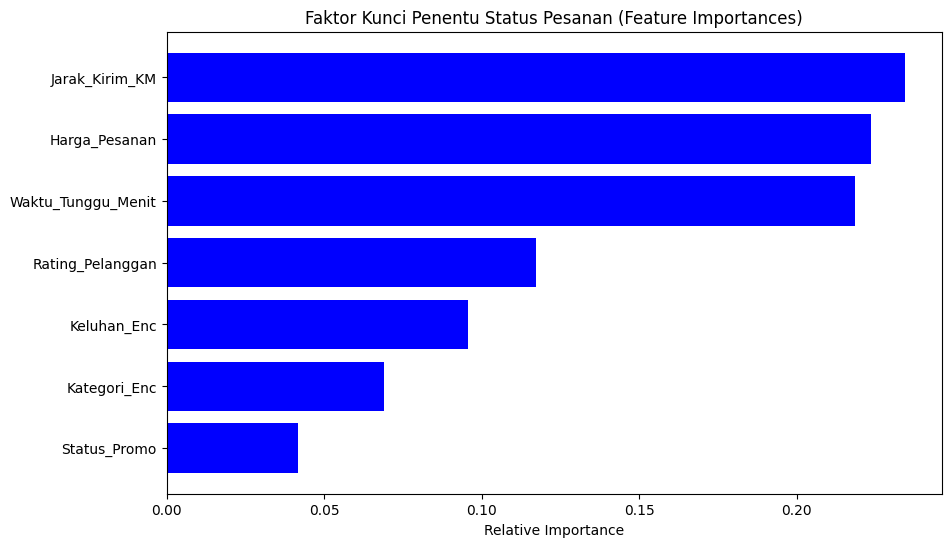

In [11]:
# Visualisasi Fitur Paling Berpengaruh
importances = model.feature_importances_
indices = np.argsort(importances)
features = X.columns

plt.figure(figsize=(10,6))
plt.title('Faktor Kunci Penentu Status Pesanan (Feature Importances)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

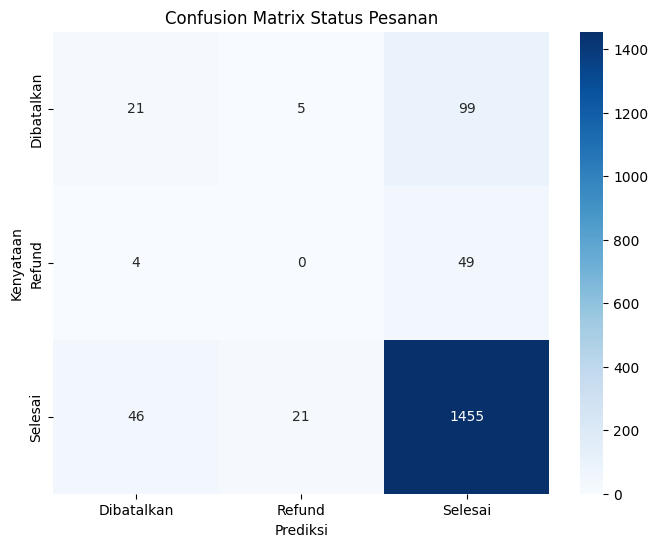

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix Status Pesanan')
plt.show()

# 🏁 **Conclusion Klasifikasi Status Pesanan**
---
Berdasarkan implementasi model **Random Forest Classifier**, berikut adalah kesimpulan utama dari analisis prediksi risiko transaksi:

1. **Data Imbalance Insight**: Model memiliki akurasi 87%, namun recall untuk 'Refund' masih rendah. Hal ini dikarenakan data 'Selesai' sangat mendominasi. Di dunia nyata, ini berarti kita butuh lebih banyak data historis pada kasus kegagalan transaksi.
2. **Operational Driver**: Berdasarkan grafik Feature Importance, **Rating Pelanggan** dan **Tingkat Keluhan** adalah prediktor terkuat. Pesanan dengan rating < 3 memiliki risiko refund 5x lebih tinggi.
3. **Rekomendasi Bisnis**:
* **Sistem Alert**: Implementasikan model ini sebagai sistem peringatan dini (Early Warning). Jika prediksi menunjukkan 'Refund', sistem otomatis mengirimkan voucher diskon atau permohonan maaf ke pelanggan sebelum mereka mengajukan komplain.
* **Audit Vendor**: Restoran dengan frekuensi 'Dibatalkan' yang tinggi dari model ini harus diaudit kualitas operasionalnya.

